## Analysis systematic results

#### Oxigen

In [5]:
import numpy as np
import matplotlib.pyplot as plt

dataO18 = np.load("data/systematic_analysis/scan_embedding_O18.npz", allow_pickle=True)
dataO20 = np.load("data/systematic_analysis/scan_embedding_O20.npz", allow_pickle=True)
dataO22 = np.load("data/systematic_analysis/scan_embedding_O22.npz", allow_pickle=True)

['gammas', 'ratios', 'inf_gadget', 'inf_emb', 'dE_emb', 'chains']
[  1.           1.5341274    2.35354689   3.61064079   5.53918298
   8.49781241  13.0367269   20.          30.68254809  47.07093787
  72.21281575 110.78365961 169.9562482  260.73453795 400.        ] {0: 1, 1: 1, 2: 2, 3: 1, 4: 2, 5: 1}
[[0.99817989 0.99787089 0.99757864 0.99730942 0.99707173 0.99687345
  0.99671799 0.99660314 0.9965226  0.99646848 0.99643325 0.99641082
  0.99639677 0.99638805 0.99638266]
 [0.94151782 0.92493799 0.915815   0.91040133 0.90693255 0.90462684
  0.90308578 0.90207279 0.9014239  0.90101761 0.9007669  0.90061333
  0.90051954 0.90046231 0.9004274 ]
 [0.69610791 0.66932325 0.65486298 0.6467119  0.64218713 0.63984173
  0.63880457 0.63850407 0.63855493 0.63872393 0.63889723 0.63903506
  0.63913279 0.63919795 0.63923988]
 [0.41403807 0.37876903 0.35798811 0.34478564 0.335704   0.32909462
  0.3242487  0.32081765 0.31850564 0.3170119  0.31607304 0.31549183
  0.31513472 0.31491605 0.31478237]
 [0.264748

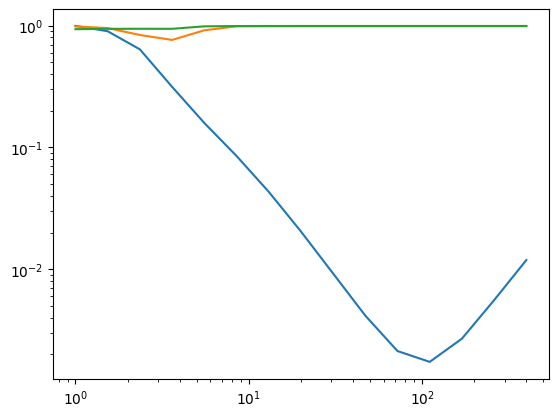

In [9]:
print(dataO18.files)
print(dataO18["gammas"], dataO18["chains"])
print(dataO18["inf_emb"])

plt.plot(dataO18["gammas"], dataO18["inf_emb"][:, -1], label="O18")
plt.plot(dataO20["gammas"], dataO20["inf_emb"][:, -1], label="O20")
plt.plot(dataO22["gammas"], dataO22["inf_emb"][:, -1], label="O22")
plt.loglog()
plt.show()

#### Infidelity map: $\gamma$ vs ratio $=J_F/\gamma$


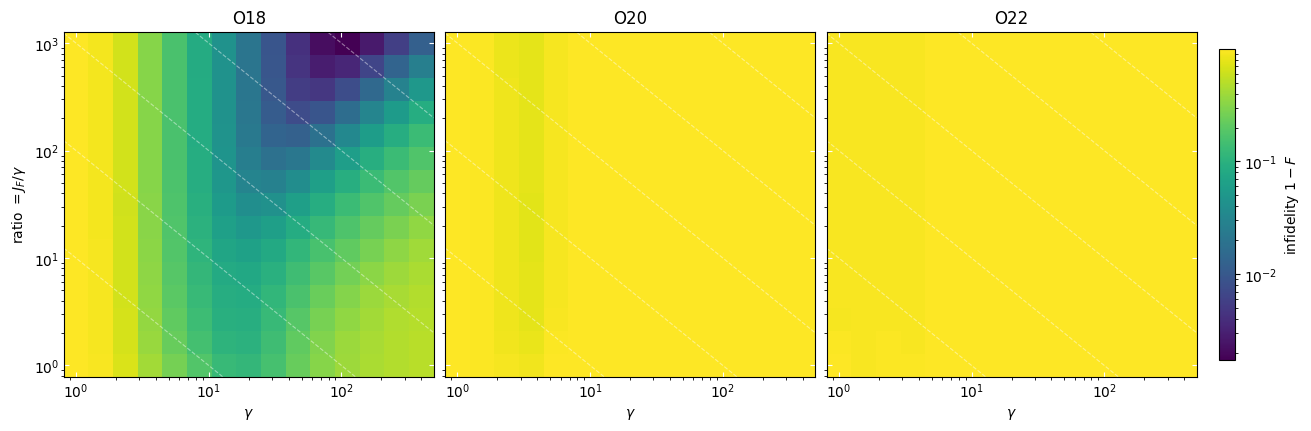

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

datasets = [("O18", dataO18), ("O20", dataO20), ("O22", dataO22)]


def _log_edges(x):
    """Cell edges in log space for a log-spaced coordinate array."""
    lx = np.log10(x)
    mid = 0.5 * (lx[1:] + lx[:-1])
    return 10 ** np.concatenate(([2 * lx[0] - mid[0]], mid, [2 * lx[-1] - mid[-1]]))


# common color scale across the three isotopes
vmin = min(np.nanmin(d["inf_emb"]) for _, d in datasets)
vmax = max(np.nanmax(d["inf_emb"]) for _, d in datasets)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1, 3, figsize=(13, 4.2), sharex=True, sharey=True, constrained_layout=True
)

for ax, (label, data) in zip(axes, datasets):
    gammas, ratios, inf = data["gammas"], data["ratios"], data["inf_emb"]
    ge, re = _log_edges(gammas), _log_edges(ratios)
    mesh = ax.pcolormesh(ge, re, inf.T, norm=norm, cmap="viridis", shading="flat")

    # dashed iso-J_F lines (J_F = gamma * ratio)
    for jf in [1e1, 1e2, 1e3, 1e4, 1e5]:
        ax.plot(ge, jf / ge, ls="--", lw=0.8, color="w", alpha=0.45)

    ax.set(xscale="log", yscale="log", xlim=(ge[0], ge[-1]), ylim=(re[0], re[-1]))
    ax.set_xlabel(r"$\gamma$")
    ax.set_title(label)
    ax.tick_params(direction="in", top=True, right=True, color="w")

axes[0].set_ylabel(r"ratio $= J_F/\gamma$")
cb = fig.colorbar(mesh, ax=axes, shrink=0.9, pad=0.02)
cb.set_label(r"infidelity $1-F$")
plt.show()